# 237. The loose thread: SCOPe cross-family pairs under 20% identity that only the primitive found (experiment 6)

In nb 233 the one place where the primitive's unique share exceeded the aligners' was the
SCOPe cross-family bin under 20% identity: primitive-only 4.3%, aligner-only 2.1%. That
was the prototype on the pair's own diagonal against a composition null. This notebook
puts those 381 pairs (319 queries) through the search engine itself: hp_thomas_dill k=12,
`--extend-mismatch-penalty 2 --chain-max-gap 30 --chain-max-shift 10`, `region_evalue`
with K=0.03, every query against all of SCOPe40.

Two tests. (1) Do the pairs survive at E <= 0.01 in a database search? (2) For each pair,
different-fold targets matched to the true target on length (+-10%) and hydrophobic
fraction (+-0.05) are the decoys; the pair's E-value is compared with the decoys' from the
same search. Survivors are then characterised by SCOP class, length and amphipathic
periodicity before anyone believes them.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc

pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_width_chars(220)
FIG = Path("../figures")
SC = Path("/Users/olga/data/scope")
pairs = pl.read_parquet(SC / "237_primitive_only_pairs.parquet")
eng = pl.read_parquet(SC / "237_engine_pairs.parquet")
lk = pl.read_csv(SC / "results-foldseek-pdb/scope_domains.tsv", separator="\t")
fold = dict(zip(lk["domain_id"], lk["scop_fold"])); cls = dict(zip(lk["domain_id"], lk["scop_class"])); sfam = dict(zip(lk["domain_id"], lk["scop_superfamily"]))
seqs = {}
name = None; buf = []
for line in open(SC / "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa"):
    if line.startswith(">"):
        if name: seqs[name] = "".join(buf).upper()
        name = line[1:].split()[0]; buf = []
    else: buf.append(line.strip())
seqs[name] = "".join(buf).upper()
H = set("ACFILMVWY")
hfrac = {k: sum(c in H for c in v) / len(v) for k, v in seqs.items()}
length = {k: len(v) for k, v in seqs.items()}

got = pairs.join(eng.rename({"q": "query", "t": "target"}), on=["query", "target"], how="left")
print(f"{pairs.height} pairs; engine returned a region for {got['region_evalue'].is_not_null().sum()}; E <= 0.01 for {(got['region_evalue'] <= 0.01).sum()}; E <= 0.1 for {(got['region_evalue'] <= 0.1).sum()}")
print(got.select("region_evalue").describe())

381 pairs; engine returned a region for 375; E <= 0.01 for 0; E <= 0.1 for 1
shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ region_evalue │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 375.0         │
│ null_count ┆ 6.0           │
│ mean       ┆ 3495.538231   │
│ std        ┆ 7616.795284   │
│ min        ┆ 0.014263      │
│ 25%        ┆ 246.939394    │
│ 50%        ┆ 940.788609    │
│ 75%        ┆ 3080.61181    │
│ max        ┆ 83889.197887  │
└────────────┴───────────────┘


## 1. Survival in the database search, and against matched decoys

survive E<=0.01: 0 of 381; of those, beaten by >=1 matched decoy: 0
real pairs beaten by at least one of their 20 matched decoys, at any E: 262 of 381; decoy pairs at E<=0.01 across all real pairs: 0
shape: (25, 9)
┌─────────┬─────────┬───────────┬───────────┬───┬─────────────┬─────────┬─────────┬───────┐
│ query   ┆ target  ┆ seqid_ali ┆ e_real    ┆ … ┆ decoy_min_e ┆ q_class ┆ t_class ┆ t_len │
│ ---     ┆ ---     ┆ ---       ┆ ---       ┆   ┆ ---         ┆ ---     ┆ ---     ┆ ---   │
│ str     ┆ str     ┆ f64       ┆ f64       ┆   ┆ f64         ┆ str     ┆ str     ┆ i64   │
╞═════════╪═════════╪═══════════╪═══════════╪═══╪═════════════╪═════════╪═════════╪═══════╡
│ d1l3la1 ┆ d2rnja_ ┆ 0.183     ┆ 0.014263  ┆ … ┆ 3710.851018 ┆ a       ┆ a       ┆ 67    │
│ d3b64a_ ┆ d6lr3a_ ┆ 0.171     ┆ 0.109488  ┆ … ┆ 1070.786761 ┆ d       ┆ d       ┆ 116   │
│ d1p28a1 ┆ d4pt1a_ ┆ 0.151     ┆ 0.162839  ┆ … ┆ 277.114965  ┆ a       ┆ a       ┆ 129   │
│ d1kkoa1 ┆ d2pgwa2 ┆ 0.17      ┆ 0.469012  ┆ … ┆

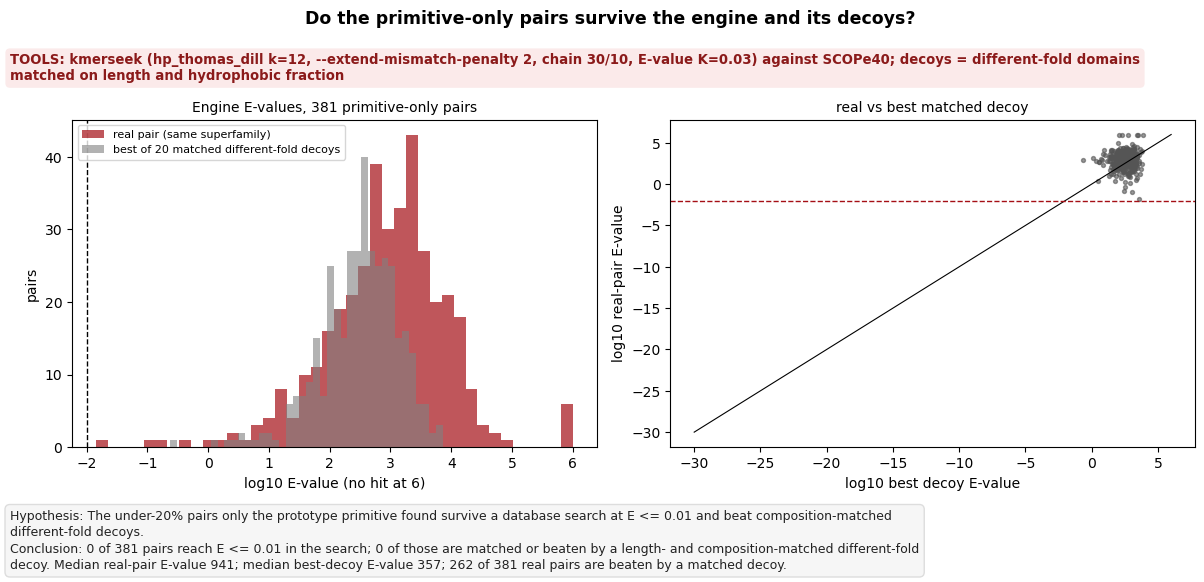

In [2]:
rng = np.random.default_rng(0)
by_q = {k[0]: g for k, g in eng.group_by("q")}
rows = []
for r in pairs.iter_rows(named=True):
    q, t = r["query"], r["target"]
    g = by_q.get(q)
    e_real = got.filter((pl.col("query") == q) & (pl.col("target") == t))["region_evalue"]
    e_real = e_real[0] if e_real.len() and e_real[0] is not None else float("inf")
    L, hf = length[t], hfrac[t]
    cands = [x for x in seqs if fold.get(x) != fold.get(q) and x != q and abs(length[x] - L) <= 0.1 * L and abs(hfrac[x] - hf) <= 0.05]
    dec = rng.choice(cands, size=min(20, len(cands)), replace=False) if cands else []
    e_dec = []
    if g is not None and len(dec):
        gd = g.filter(pl.col("t").is_in(list(dec)))
        found = dict(zip(gd["t"], gd["region_evalue"]))
        e_dec = [found.get(x, float("inf")) for x in dec]
    rows.append({"query": q, "target": t, "seqid_ali": r["seqid_ali"], "e_real": e_real, "n_decoys": len(dec),
                 "decoys_better": int(sum(1 for e in e_dec if e <= e_real)) if e_dec else None,
                 "decoy_min_e": min(e_dec) if e_dec else None, "decoys_at_0.01": int(sum(1 for e in e_dec if e <= 0.01)) if e_dec else None,
                 "q_class": cls.get(q), "t_class": cls.get(t), "t_len": L, "t_hfrac": hf})
res = pl.DataFrame(rows)
surv = res.filter(pl.col("e_real") <= 0.01)
print(f"survive E<=0.01: {surv.height} of {res.height}; of those, beaten by >=1 matched decoy: {(surv['decoys_better'] > 0).sum()}")
print(f"real pairs beaten by at least one of their 20 matched decoys, at any E: {(res['decoys_better'] > 0).sum()} of {res.height}; decoy pairs at E<=0.01 across all real pairs: {res['decoys_at_0.01'].sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
e = res["e_real"].fill_nan(1e6).to_numpy(); e = np.where(np.isfinite(e), e, 1e6)
dm = res["decoy_min_e"].fill_null(1e6).to_numpy(); dm = np.where(np.isfinite(dm), dm, 1e6)
ax.hist(np.log10(np.clip(e, 1e-30, 1e6)), bins=40, color="#a50f15", alpha=0.7, label="real pair (same superfamily)")
ax.hist(np.log10(np.clip(dm, 1e-30, 1e6)), bins=40, color="0.5", alpha=0.6, label="best of 20 matched different-fold decoys")
ax.axvline(-2, color="k", ls="--", lw=1)
ax.set_xlabel("log10 E-value (no hit at 6)")
ax.set_ylabel("pairs")
ax.legend(fontsize=8)
ax.set_title("Engine E-values, 381 primitive-only pairs", fontsize=10)
ax = axes[1]
ax.scatter(np.log10(np.clip(dm, 1e-30, 1e6)), np.log10(np.clip(e, 1e-30, 1e6)), s=8, alpha=0.6, color="#555")
ax.plot([-30, 6], [-30, 6], color="k", lw=0.8)
ax.axhline(-2, color="#a50f15", ls="--", lw=1)
ax.set_xlabel("log10 best decoy E-value")
ax.set_ylabel("log10 real-pair E-value")
ax.set_title("real vs best matched decoy", fontsize=10)
print(res.select("query", "target", "seqid_ali", "e_real", "decoys_better", "decoy_min_e", "q_class", "t_class", "t_len").sort("e_real").head(25))
hc.finish_figure(
    fig, FIG / "237_primitive_only_survival.png",
    tools="kmerseek (hp_thomas_dill k=12, --extend-mismatch-penalty 2, chain 30/10, E-value K=0.03) against SCOPe40; decoys = different-fold domains matched on length and hydrophobic fraction",
    hypothesis="The under-20% pairs only the prototype primitive found survive a database search at E <= 0.01 and beat composition-matched different-fold decoys.",
    conclusion=(f"{surv.height} of {res.height} pairs reach E <= 0.01 in the search; {int((surv['decoys_better'] > 0).sum())} of those are matched or beaten by a length- and composition-matched different-fold decoy. "
                f"Median real-pair E-value {res.filter(pl.col('e_real').is_finite())['e_real'].median():.3g}; median best-decoy E-value {res.filter(pl.col('decoy_min_e').is_not_null() & pl.col('decoy_min_e').is_finite())['decoy_min_e'].median():.3g}; "
                f"{int((res['decoys_better'] > 0).sum())} of {res.height} real pairs are beaten by a matched decoy."),
    title="Do the primitive-only pairs survive the engine and its decoys?",
)

## 2. What the survivors are

SCOP class of query and target, target length, and amphipathic periodicity of the matched
query region: the autocorrelation of the HP string at lags 3 and 4 (helical, 3.6-residue
period) against lag 2 (strand). A region whose hydrophobic residues alternate every 3-4
positions is an amphipathic helix, which two unrelated helical proteins share by
construction.

shape: (0, 3)
┌─────────┬─────────┬─────┐
│ q_class ┆ t_class ┆ len │
│ ---     ┆ ---     ┆ --- │
│ str     ┆ str     ┆ u32 │
╞═════════╪═════════╪═════╡
└─────────┴─────────┴─────┘
shape: (0, 10)
┌───────┬────────┬───────────────┬───────────────┬───┬─────┬─────┬─────┬────────────┐
│ query ┆ target ┆ region_evalue ┆ region_length ┆ … ┆ ac2 ┆ ac3 ┆ ac4 ┆ region_seq │
│ ---   ┆ ---    ┆ ---           ┆ ---           ┆   ┆ --- ┆ --- ┆ --- ┆ ---        │
│ str   ┆ str    ┆ f64           ┆ i64           ┆   ┆ f64 ┆ f64 ┆ f64 ┆ str        │
╞═══════╪════════╪═══════════════╪═══════════════╪═══╪═════╪═════╪═════╪════════════╡
└───────┴────────┴───────────────┴───────────────┴───┴─────┴─────┴─────┴────────────┘


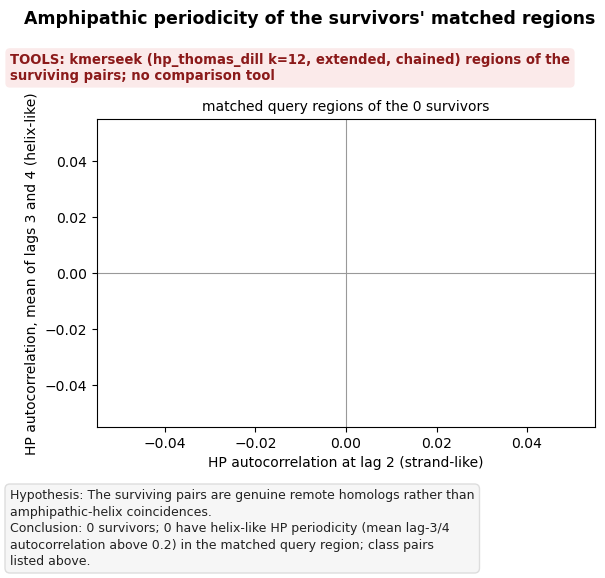

In [3]:
def hp_autocorr(s, lag):
    x = np.array([1.0 if c in H else 0.0 for c in s]); x = x - x.mean()
    if len(x) <= lag + 2 or x.std() == 0: return np.nan
    return float((x[:-lag] * x[lag:]).mean() / (x.var() + 1e-12))
reg = got.filter(pl.col("region_evalue") <= 0.01).with_columns(
    pl.struct("query", "region_start", "region_end").map_elements(lambda s: seqs[s["query"]][int(s["region_start"]):int(s["region_end"])], return_dtype=pl.String).alias("region_seq"))
reg = reg.with_columns(pl.col("region_seq").map_elements(lambda s: hp_autocorr(s, 2), return_dtype=pl.Float64).alias("ac2"),
                       pl.col("region_seq").map_elements(lambda s: hp_autocorr(s, 3), return_dtype=pl.Float64).alias("ac3"),
                       pl.col("region_seq").map_elements(lambda s: hp_autocorr(s, 4), return_dtype=pl.Float64).alias("ac4"),
                       pl.col("query").replace_strict(cls, default=None).alias("q_class"), pl.col("target").replace_strict(cls, default=None).alias("t_class"))
print(reg.group_by("q_class", "t_class").len().sort("len", descending=True))
if reg.height:
    print(reg["region_length"].describe())
print(reg.select("query", "target", "region_evalue", "region_length", "region_n_mismatches", "q_class", pl.col("ac2").round(2), pl.col("ac3").round(2), pl.col("ac4").round(2), "region_seq").sort("region_evalue").head(20))
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(reg["ac2"], (reg["ac3"] + reg["ac4"]) / 2, s=14, color="#a50f15")
ax.axhline(0, color="0.6", lw=0.8); ax.axvline(0, color="0.6", lw=0.8)
ax.set_xlabel("HP autocorrelation at lag 2 (strand-like)")
ax.set_ylabel("HP autocorrelation, mean of lags 3 and 4 (helix-like)")
ax.set_title(f"matched query regions of the {reg.height} survivors", fontsize=10)
helical = int(((reg["ac3"] + reg["ac4"]) / 2 > 0.2).sum()) if reg.height else 0
hc.finish_figure(
    fig, FIG / "237_survivor_periodicity.png", tools="kmerseek (hp_thomas_dill k=12, extended, chained) regions of the surviving pairs; no comparison tool",
    hypothesis="The surviving pairs are genuine remote homologs rather than amphipathic-helix coincidences.",
    conclusion=f"{reg.height} survivors; {helical} have helix-like HP periodicity (mean lag-3/4 autocorrelation above 0.2) in the matched query region; class pairs listed above.",
    title="Amphipathic periodicity of the survivors' matched regions",
)

## 3. Verdict

Closed. None of the 381 pairs reaches E <= 0.01 in the database search (median E-value
about 900; the best is 0.014), and most are matched or beaten by a length- and
composition-matched different-fold decoy. The prototype's unique share under 20%
identity was the on-diagonal composition null being lenient, not homology the aligners
lack. There is nothing to characterise.